In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
from pathlib import Path
from PIL import Image
import matplotlib.pylab as plt
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
from tqdm import tqdm

In [48]:
DATA_ROOT = Path("/content/drive/MyDrive")
TRAIN_PATH=DATA_ROOT/"train"
TEST_PATH=DATA_ROOT/"test"
EVAL_PATH=DATA_ROOT/"eval"

In [49]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [50]:
for folder in TRAIN_PATH.iterdir():
  print(folder.name)

forest
buildings
mountain
street
glacier
sea


In [51]:
train_images=list(TRAIN_PATH.rglob("*.jpg"))
print(f"The total number of train images are:{len(train_images)}")

The total number of train images are:14034


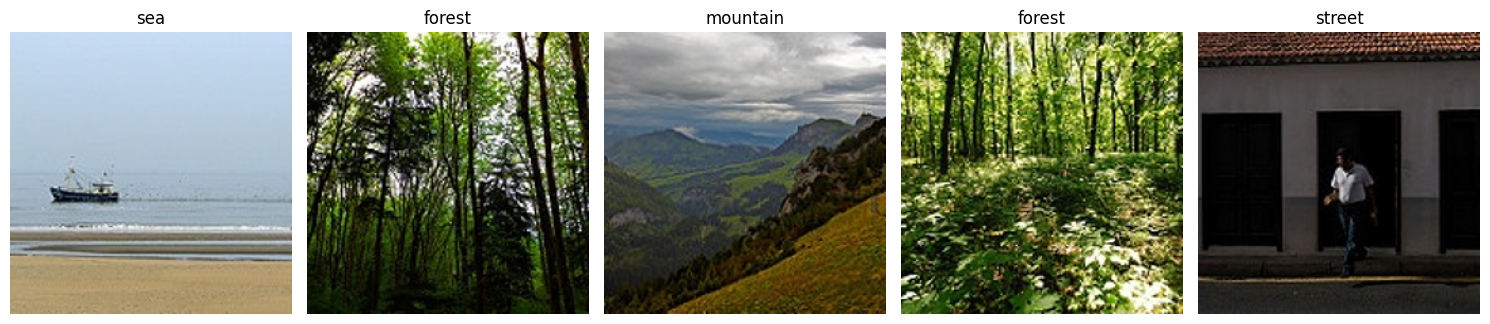

In [52]:
fig,axes=plt.subplots(1,5,figsize=(15,6))

for img in range(5):
  image=random.choice(train_images)
  image_path=image.parent.name
  image=Image.open(image).convert("RGB").resize((224,224))

  axes[img].imshow(image)
  axes[img].set_title(image_path)
  axes[img].axis('off')

plt.tight_layout()
plt.show()

In [53]:
class CustomDataset(Dataset):

  def __init__(self,root_path,transformation):
    super().__init__()
    self.root_path=Path(root_path)
    self.transformation=transformation
    self.labels=[]
    self.image_path=[]

    classes=["sea","glacier","forest","street","mountain","buildings"]

    for index,class_name in enumerate(classes):
      class_folder=self.root_path/class_name

      for img in class_folder.iterdir():
        if img.suffix.lower() in [".jpeg",".jpg",".png"]:
          self.image_path.append(img)
          self.labels.append(index)

  def __len__(self):
    return len(self.image_path)

  def __getitem__(self,index):
    image = Image.open(self.image_path[index]).convert("RGB")
    label=self.labels[index]

    if self.transformation:
      image=self.transformation(image)

    return image,label

In [54]:
class SimpleModel(nn.Module):
    def __init__(self, num_classes=6):
      super().__init__()
      self.feature=nn.Sequential(
          nn.Conv2d(3,128,3,padding='same'),
          nn.BatchNorm2d(128),
          nn.ReLU(),
          nn.Dropout(0.4),
          nn.MaxPool2d(2),

          nn.Conv2d(128,64,3,padding='same'),
          nn.BatchNorm2d(64),
          nn.ReLU(),
          nn.Dropout(0.3),
          nn.MaxPool2d(2),
      )
      self.classifier=nn.Sequential(
          nn.Flatten(),
          nn.Linear(16*16*64,num_classes)
      )

    def forward(self,x):
      output=self.feature(x)
      output=self.classifier(output)

      return output


In [55]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

In [56]:
train_data=CustomDataset(TRAIN_PATH,transform)
eval_data=CustomDataset(EVAL_PATH,transform)

In [57]:
train_dataloader=DataLoader(train_data,batch_size=64,shuffle=True,pin_memory=True,num_workers=0)
eval_dataloader=DataLoader(eval_data,batch_size=64,shuffle=False,pin_memory=True,num_workers=0)

In [58]:
epochs=10
learning_rate=1e-4
loss=nn.CrossEntropyLoss()
model = SimpleModel(num_classes=6)
model=model.to(device)
optimizer=optim.Adam(model.parameters(),lr=learning_rate)

In [59]:
history={'train_loss':[],'train_accuracy':[],'eval_loss':[],'eval_accuracy':[]}

for epoch in range(epochs):
  model.train()
  t_correct,t_loss,t_count=0,0,0
  for batch_feature,batch_label in tqdm(train_dataloader):
    batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
    optimizer.zero_grad()
    output=model(batch_feature)
    model_loss=loss(output,batch_label)
    model_loss.backward()
    optimizer.step()

    # Calculate accuracy:
    _,predicted=torch.max(output,1)
    t_count+=batch_feature.shape[0]
    t_correct+=(predicted==batch_label).sum().item()
    t_loss+=model_loss.item()

  model.eval()
  v_correct,v_loss,v_count=0,0,0
  with torch.no_grad():
      for batch_feature,batch_label in eval_dataloader:
        batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
        output=model(batch_feature)
        model_loss=loss(output,batch_label)

        # Calculate accuracy:
        _,predicted=torch.max(output,1)
        v_count+=batch_feature.shape[0]
        v_correct+=(predicted==batch_label).sum().item()
        v_loss+=model_loss.item()

  history['train_loss'].append(t_loss/len(train_dataloader))
  history['eval_loss'].append(v_loss/len(eval_dataloader))
  history['train_accuracy'].append(t_correct/t_count)
  history['eval_accuracy'].append(v_correct/v_count)

  print(f"Epochs {epoch+1}  | Train Accuracy:{history['train_accuracy'][-1]:.2f} | Train Loss:{history['train_loss'][-1]:.2f} | Eval Accuracy:{history['eval_accuracy'][-1]:.2f} | Eval Loss:{history['eval_loss'][-1]:.2f}")

100%|██████████| 220/220 [01:13<00:00,  2.97it/s]


Epochs 1  | Train Accuracy:0.64 | Train Loss:0.97 | Eval Accuracy:0.68 | Eval Loss:0.90


100%|██████████| 220/220 [00:58<00:00,  3.77it/s]


Epochs 2  | Train Accuracy:0.72 | Train Loss:0.76 | Eval Accuracy:0.71 | Eval Loss:0.85


100%|██████████| 220/220 [00:58<00:00,  3.74it/s]


...

Epochs 8  | Train Accuracy:0.84 | Train Loss:0.45 | Eval Accuracy:0.77 | Eval Loss:0.64


100%|██████████| 220/220 [00:55<00:00,  3.99it/s]


Epochs 9  | Train Accuracy:0.85 | Train Loss:0.43 | Eval Accuracy:0.76 | Eval Loss:0.69


100%|██████████| 220/220 [00:55<00:00,  3.97it/s]


Epochs 10  | Train Accuracy:0.86 | Train Loss:0.40 | Eval Accuracy:0.75 | Eval Loss:0.69


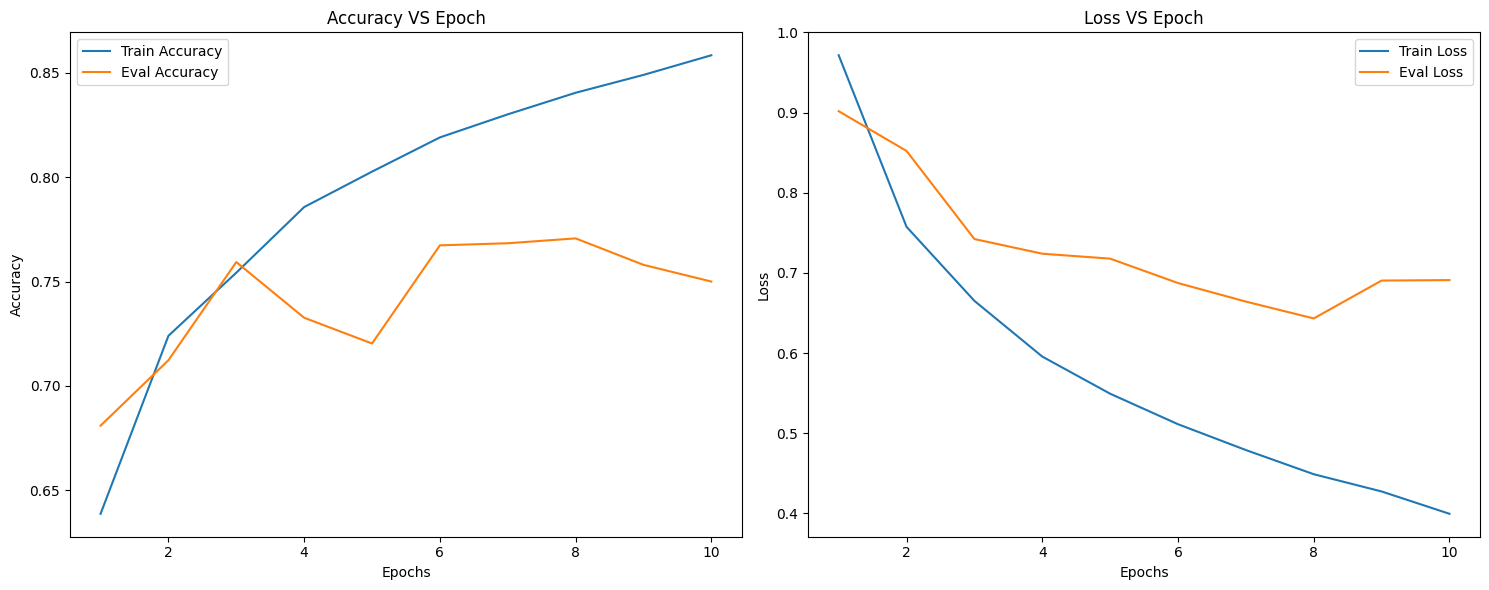

In [60]:
fig,axes=plt.subplots(1,2,figsize=(15,6))

axes[0].plot(range(1,epochs+1),history['train_accuracy'],label="Train Accuracy")
axes[0].plot(range(1,epochs+1),history['eval_accuracy'],label="Eval Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy VS Epoch")
axes[0].legend()

axes[1].plot(range(1,epochs+1),history['train_loss'],label="Train Loss")
axes[1].plot(range(1,epochs+1),history['eval_loss'],label="Eval Loss")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss VS Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [61]:
def predict_test_data(root_path):
  classes=["sea","glacier","forest","street","mountain","buildings"]
  fig,axes=plt.subplots(2,5,figsize=(15,6))
  # 1) Choose 10 image randomly
  model.eval()
  img_list=list(root_path.rglob("*.jpg"))
  for img in range(10):
    image=random.choice(img_list)
    image=Image.open(image).convert("RGB")
    img_tensor=transform(image).unsqueeze(0).to(device)
  # 2) Send it to the model to predict
    with torch.no_grad():
      output=model(img_tensor)

      _,predicted_index=torch.max(output,1)
      predicted_label=classes[predicted_index.item()]

      ax=axes[img//5,img%5]
      ax.imshow(image)
      ax.set_title(f"Guess: {predicted_label}")
      ax.axis('off')

  plt.tight_layout()
  plt.show()
  # 3) Since the test data doesnot have labels, your eyes are ground truth

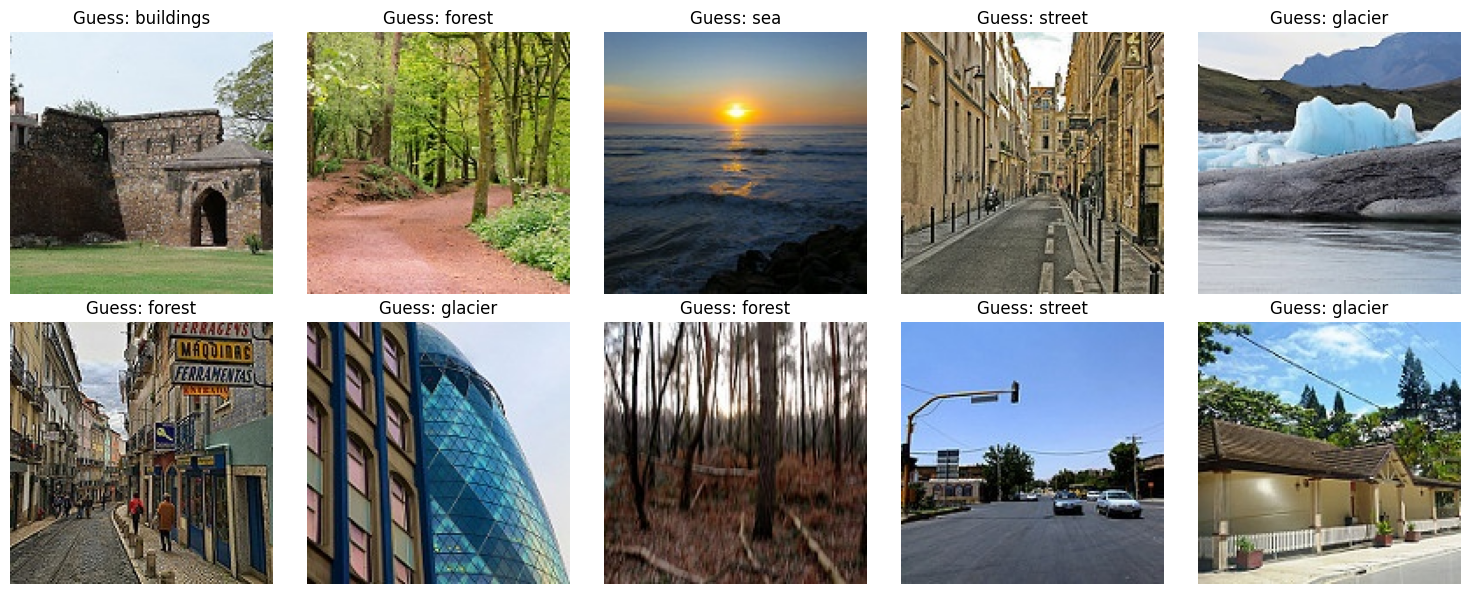

In [62]:
predict_test_data(TEST_PATH)

I have added some regularization techniques like: Dropout and BatchNormalization in this architecture to see it's effect. Moreover, I have also added Relu to introduce some non-linearties. Average guessing with give us a accuracy of 1/6=0.16, but here we can see out model evolve. In this case the eval accuracy reached to 0.77 compared to last time when it was only 0.70. Also, the training accuracy has reached 0.86,however,there seems to be some overfitting.